<a href="https://colab.research.google.com/github/nblchmsr-ctrl/mobilenetv3-large-transfer-learning/blob/main/MobileNetV3_Large_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_raw(2).zip to dataset_raw(2).zip


In [3]:
import zipfile
import os

zip_path = "dataset_raw(2).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak!")
print("Isi folder:")
print(os.listdir(extract_path))

Dataset berhasil diekstrak!
Isi folder:
['dataset_raw']


In [4]:
data_path = "/content/dataset/dataset_raw"

print("Isi dataset:")
print(os.listdir(data_path))

Isi dataset:
['box', 'botol']


In [5]:
import os

DATA_DIR = "/content/dataset/dataset_raw"

print("Kelas:", os.listdir(DATA_DIR))

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        print(f"{class_name}: {len(files)} gambar")

Kelas: ['box', 'botol']
botol: 50 gambar
box: 50 gambar


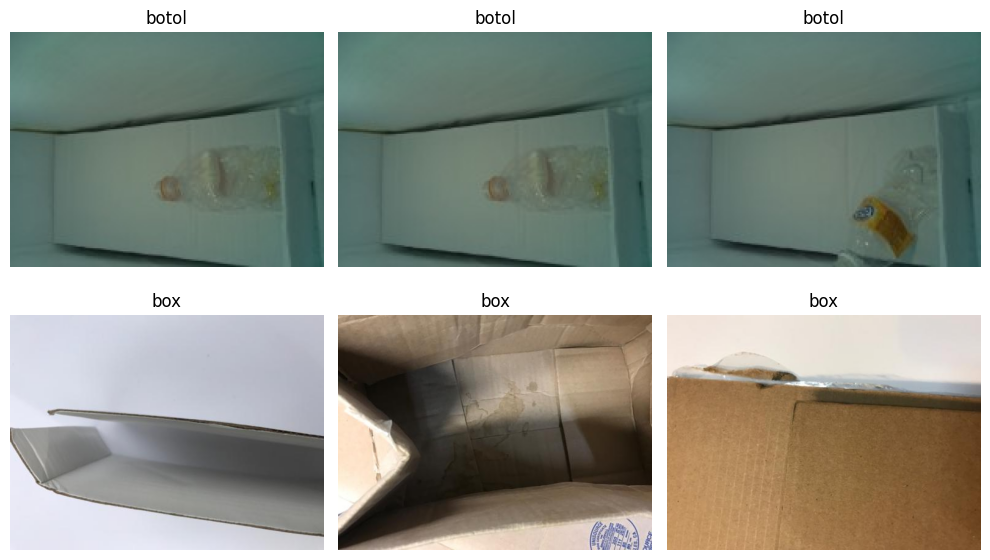

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

class_names = sorted([
    name for name in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, name))
])

plt.figure(figsize=(10, 6))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    for j in range(3):
        image_name = random.choice(image_files)
        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        position = i * 3 + j + 1
        plt.subplot(2, 3, position)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

records = []

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):
            records.append({
                "path": os.path.join(class_path, file_name),
                "label": class_name
            })

df = pd.DataFrame(records)

print("Total gambar:", len(df))
print("\nJumlah tiap kelas:")
print(df["label"].value_counts())

Total gambar: 100

Jumlah tiap kelas:
label
botol    50
box      50
Name: count, dtype: int64


In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

class_to_idx = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

train_df["label_id"] = train_df["label"].map(class_to_idx)
val_df["label_id"] = val_df["label"].map(class_to_idx)
test_df["label_id"] = test_df["label"].map(class_to_idx)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nMapping kelas:")
print(class_to_idx)

Train      : 70
Validation : 15
Test       : 15

Mapping kelas:
{'botol': 0, 'box': 1}


In [9]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

class_to_idx = {
    class_name: i
    for i, class_name in enumerate(class_names)
}

train_df["label_id"] = train_df["label"].map(class_to_idx)
val_df["label_id"] = val_df["label"].map(class_to_idx)
test_df["label_id"] = test_df["label"].map(class_to_idx)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nMapping kelas:")
print(class_to_idx)

Train      : 70
Validation : 15
Test       : 15

Mapping kelas:
{'botol': 0, 'box': 1}


In [10]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["path"].values
    labels = dataframe["label_id"].values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Dataset TensorFlow berhasil dibuat.")

Dataset TensorFlow berhasil dibuat.


In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation siap.")

Data augmentation siap.


In [12]:
from tensorflow.keras.applications import MobileNetV3Large

base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV3-Large berhasil dimuat.")
print("Jumlah layer:", len(base_model.layers))

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3-Large berhasil dimuat.
Jumlah layer: 187


In [13]:
base_model.trainable = False

print("Backbone MobileNetV3-Large dibekukan.")

Backbone MobileNetV3-Large dibekukan.


In [14]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    2,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,618 (11.90 MB)

 Trainable params: 123,266 (481.51 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [15]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    2,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       123,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,119,618 (11.90 MB)

 Trainable params: 123,266 (481.51 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


In [17]:
callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [18]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_stage1
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 609ms/step - accuracy: 0.7000 - loss: 0.7511 - val_accuracy: 0.9333 - val_loss: 0.1622 - learning_rate: 0.0010
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0806 - val_accuracy: 1.0000 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.000

In [19]:
base_model.trainable = True

fine_tune_from = len(base_model.layers) - 40

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

print("Fine-tuning siap.")
print(
    "Layer yang dapat dilatih:",
    sum(layer.trainable for layer in base_model.layers)
)

Fine-tuning siap.
Layer yang dapat dilatih: 32


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [22]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_stage2
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 998ms/step - accuracy: 1.0000 - loss: 9.1612e-04 - val_accuracy: 1.0000 - val_loss: 2.8727e-04 - learning_rate: 1.0000e-05
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 1.0000 - loss: 6.4846e-04 - val_accuracy: 1.0000 - val_loss: 2.4908e-04 - learning_rate: 1.0000e-05
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 2.0947e-04 - val_accuracy: 1.0000 - val_loss: 2.4125e-04 - learning_rate: 1.0000e-05
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 2.3834e-04 - learning_rate: 2.0000e-06
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 5.7700e-04 - val_accuracy: 1.0000 - val_loss: 2.3291e-04 - learning_rate: 2.0000e-06
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 2.6355e-04 - val_accuracy: 1.0000 - val_loss: 2.3208e-04 - learning_rate: 4.0000e-07
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 

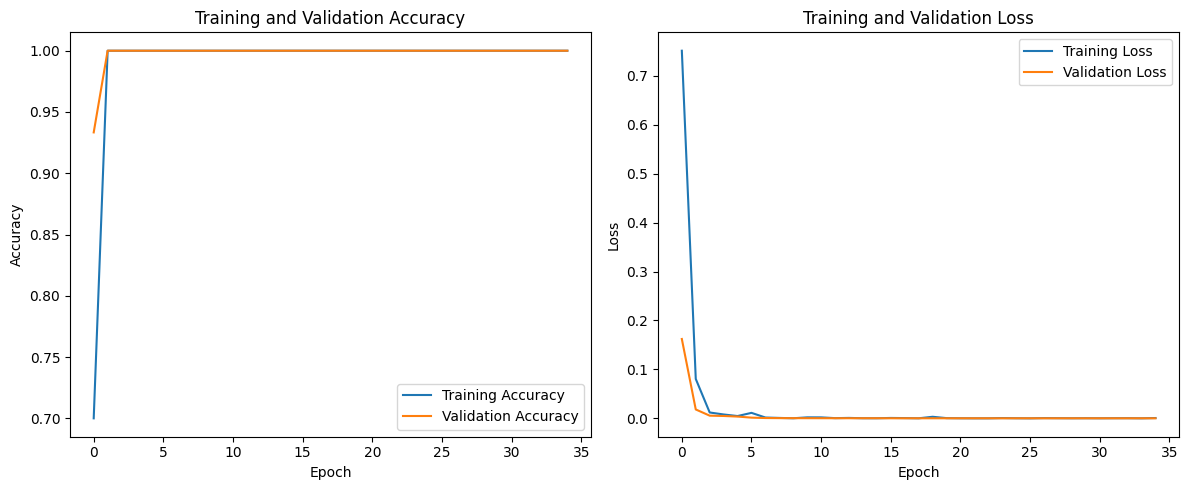

In [23]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== HASIL TEST ==========")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 1.0194e-04

========== HASIL TEST ==========
Test Loss     : 0.0001
Test Accuracy : 1.0000
Test Accuracy : 100.00%


In [25]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       botol     1.0000    1.0000    1.0000         8
         box     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        15
   macro avg     1.0000    1.0000    1.0000        15
weighted avg     1.0000    1.0000    1.0000        15



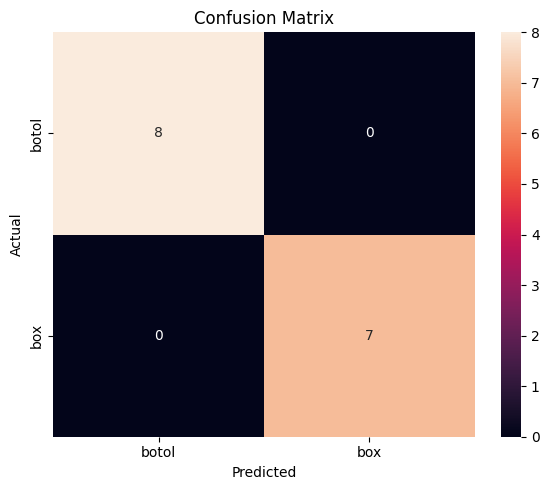

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

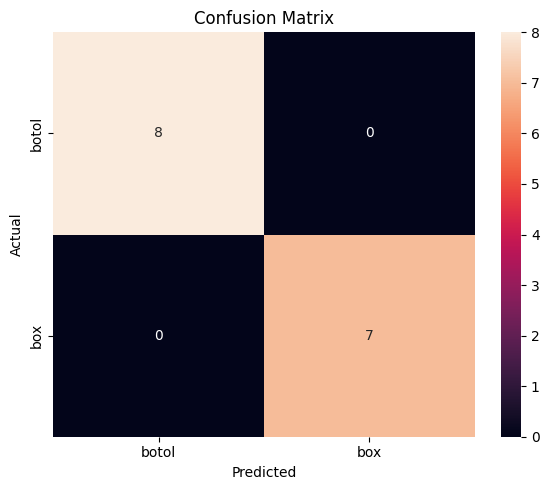

In [27]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/content/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
import os
import json

RESULT_DIR = "/content/results"

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

In [29]:
model_path = os.path.join(
    RESULT_DIR,
    "mobilenetv3_large_botol_box.keras"
)

model.save(model_path)

print("Model berhasil disimpan:")
print(model_path)

Model berhasil disimpan:
/content/results/mobilenetv3_large_botol_box.keras


In [30]:
with open(
    os.path.join(
        RESULT_DIR,
        "class_names.json"
    ),
    "w"
) as f:
    json.dump(
        class_names,
        f,
        indent=4
    )

print("Class names berhasil disimpan.")

Class names berhasil disimpan.


In [31]:
import pandas as pd

history_df = pd.DataFrame({
    "accuracy": acc,
    "val_accuracy": val_acc,
    "loss": loss,
    "val_loss": val_loss
})

history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "training_history.csv"
    ),
    index=False
)

print("Training history berhasil disimpan.")

Training history berhasil disimpan.


In [32]:
readme_text = f"""# MobileNetV3-Large Transfer Learning

## Image Classification: Botol vs Box

Proyek ini merupakan implementasi metode **Transfer Learning** menggunakan **MobileNetV3-Large** untuk melakukan klasifikasi gambar menjadi dua kelas, yaitu botol dan box.

## Dataset

Dataset terdiri dari:

- Botol: 50 gambar
- Box: 50 gambar
- Total: 100 gambar

Dataset dibagi menjadi:

- 70% training
- 15% validation
- 15% testing

## Model

Model yang digunakan adalah:

**MobileNetV3-Large pretrained on ImageNet**

Tahapan model:

1. MobileNetV3-Large digunakan sebagai pretrained feature extractor.
2. Backbone dibekukan pada tahap training awal.
3. Ditambahkan Global Average Pooling.
4. Ditambahkan Dense layer 128 neuron.
5. Dropout digunakan untuk mengurangi overfitting.
6. Fine-tuning dilakukan pada sebagian layer akhir MobileNetV3-Large.
7. Output akhir terdiri dari 2 kelas: botol dan box.

## Training

Training dilakukan menggunakan Google Colab dengan GPU.

Optimizer:

**Adam**

Learning rate awal:

**0.001**

Learning rate fine-tuning:

**0.00001**

Image size:

**224 x 224 pixels**

## Hasil

Test Accuracy:

**{test_accuracy * 100:.2f}%**

Hasil evaluasi lainnya dapat dilihat pada:

- Classification Report
- Confusion Matrix
- Training History

## Files

- `MobileNetV3_Large_Transfer_Learning.ipynb` — notebook Google Colab
- `mobilenetv3_large_botol_box.keras` — model hasil training
- `class_names.json` — nama kelas
- `training_history.csv` — data training
- `confusion_matrix.png` — confusion matrix

## Tools

- Python
- TensorFlow / Keras
- MobileNetV3-Large
- Scikit-learn
- Google Colab
- GitHub
"""

with open(
    "/content/README.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_text)

print(readme_text)

# MobileNetV3-Large Transfer Learning

## Image Classification: Botol vs Box

Proyek ini merupakan implementasi metode **Transfer Learning** menggunakan **MobileNetV3-Large** untuk melakukan klasifikasi gambar menjadi dua kelas, yaitu botol dan box.

## Dataset

Dataset terdiri dari:

- Botol: 50 gambar
- Box: 50 gambar
- Total: 100 gambar

Dataset dibagi menjadi:

- 70% training
- 15% validation
- 15% testing

## Model

Model yang digunakan adalah:

**MobileNetV3-Large pretrained on ImageNet**

Tahapan model:

1. MobileNetV3-Large digunakan sebagai pretrained feature extractor.
2. Backbone dibekukan pada tahap training awal.
3. Ditambahkan Global Average Pooling.
4. Ditambahkan Dense layer 128 neuron.
5. Dropout digunakan untuk mengurangi overfitting.
6. Fine-tuning dilakukan pada sebagian layer akhir MobileNetV3-Large.
7. Output akhir terdiri dari 2 kelas: botol dan box.

## Training

Training dilakukan menggunakan Google Colab dengan GPU.

Optimizer:

**Adam**

Learning rate awal:



In [33]:
import shutil

shutil.make_archive(
    "/content/MobileNetV3_Large_Project_Results",
    "zip",
    RESULT_DIR
)

print("ZIP hasil berhasil dibuat.")

ZIP hasil berhasil dibuat.


In [35]:
from google.colab import files

files.download(
    "/content/MobileNetV3_Large_Project_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>